In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dt=pd.read_csv("adult.csv")


In [3]:
dt.shape

(48842, 15)

In [4]:
dt.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## About the Dataset

| Column | Description |
|---|---|
| **age** | Age of individual (Continuous) |
| **workclass** | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked |
| **fnlwgt** | Final weight (Continuous) |
| **education** | Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool |
| **education-num** | Number of years spent in education (Continuous) |
| **marital-status** | Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse |
| **occupation** | Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces |
| **relationship** | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried |
| **race** | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black |
| **sex** | Female, Male |
| **capital-gain** | Continuous |
| **capital-loss** | Continuous |
| **hours-per-week** | Continuous |
| **native-country** | United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands |
| **salary** | Target variable: `>50K`, `<=50K` |

In [5]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


#### Although there is no any null values the dataset contains '?' in many places

In [6]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


## Observation


- The minimum and maximum age of people in the dataset is 19 and 90 years respectively, while the average age is 37.
- The minimum and maximum years spent on education is 1 and 16 respectively, whereas the mean education level is 10 years.
- While the minimum and average capital gain is 0, maximum is 99999. This seems odd, maybe some error within the data collection.
- The number of hours spent per week varies between 1 to 99 and the average being 40 hours.

In [7]:
dt['workclass'].unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [8]:
dt = dt.replace('?', np.nan)

**Replacing the '?' with null**

In [9]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [10]:
dt.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [11]:
dt['workclass'] = dt['workclass'].fillna(dt['workclass'].mode()[0])
dt['occupation'] = dt['occupation'].fillna(dt['occupation'].mode()[0])
dt['native-country'] = dt['native-country'].fillna(dt['native-country'].mode()[0])

**Filling the null values using their respective mode value**

In [12]:
dt.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [13]:
dt.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [14]:
dt.rename(columns={
    'educational-num':'educational_num',
    'marital-status' : 'marital_status',
    'capital-gain' :'capital_gain',
    'capital-loss' : 'capital-loss',
    'hours-per-week': 'hours_per_week',
    'native-country': 'native-country'
},inplace=True)

**Replacing '-' with '_' of columns**

In [15]:
dt.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital-loss', 'hours_per_week', 'native-country',
       'income'],
      dtype='object')

## EDA

In [16]:
dt['race'].value_counts()

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

Text(0.5, 1.0, 'Race Distribution')

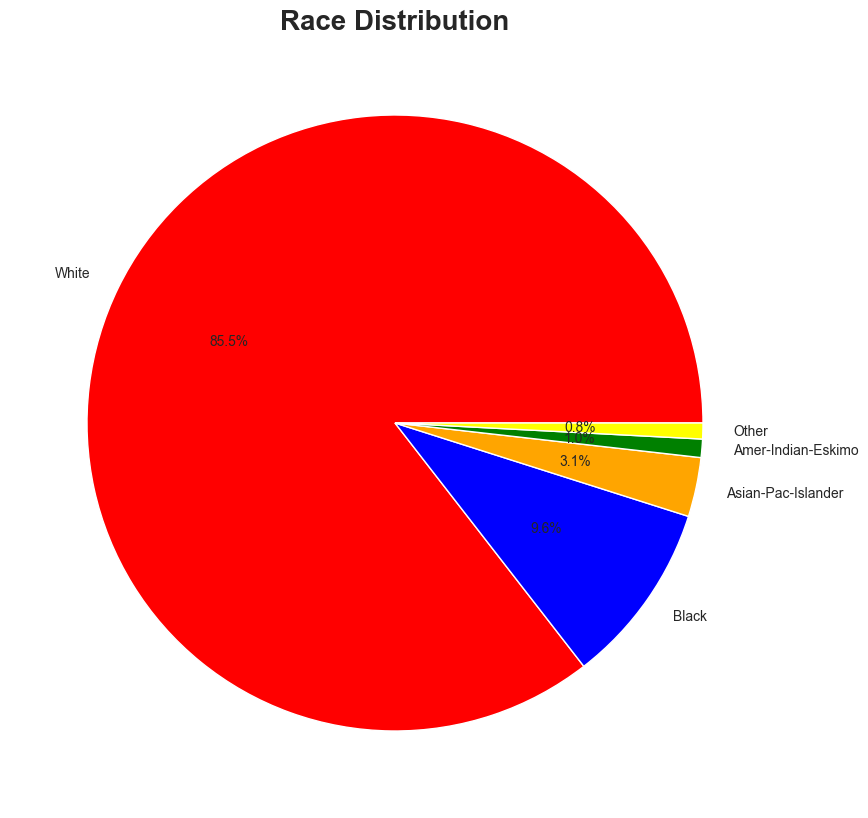

In [18]:
plt.figure(figsize = (10, 10))
#sns.set_style("whitegrid")
plt.pie(dt['race'].value_counts(), labels = dt['race'].value_counts().index, autopct = '%1.1f%%', colors=['red', 'blue', 'orange', 'green', 'yellow'])
plt.title('Race Distribution', fontsize=20, fontweight='bold')

In [19]:
dt['marital_status'].value_counts()

marital_status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

Text(0.5, 1.0, 'Race Distribution')

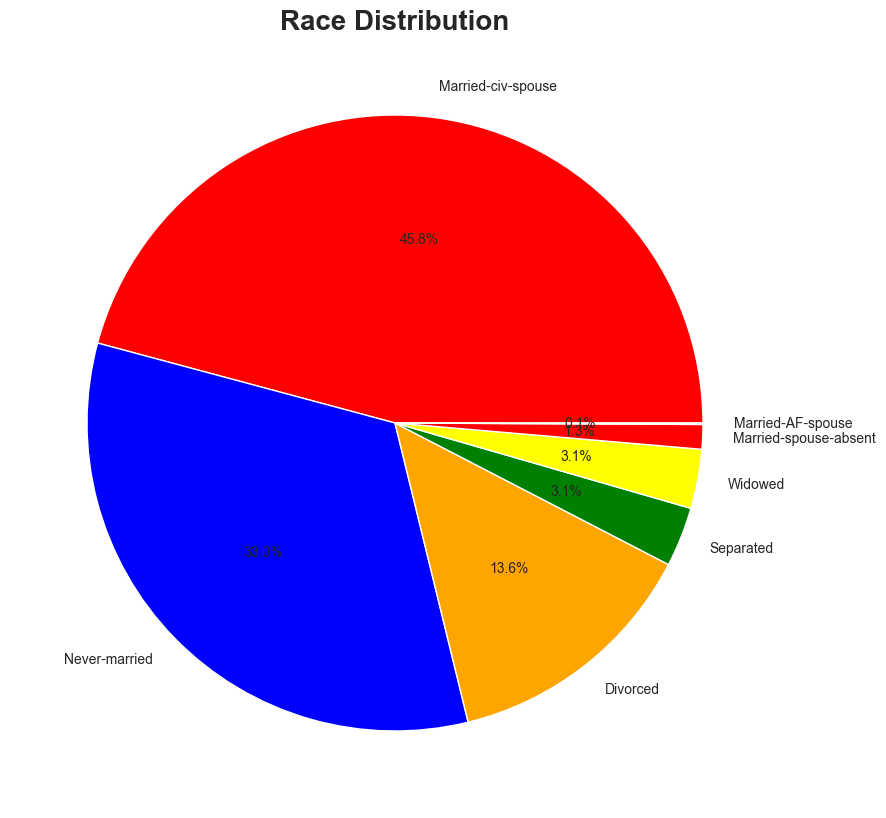

In [20]:
plt.figure(figsize = (10, 10))
plt.pie(dt['marital_status'].value_counts(), labels = dt['marital_status'].value_counts().index, autopct = '%1.1f%%', colors=['red', 'blue', 'orange', 'green', 'yellow'])

C:\Users\Mitrahang\AppData\Local\Temp\ipykernel_21332\1279262628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'income', y = 'Percentage', data = eda_percentage.head(10), palette='Reds')


<Axes: title={'center': 'Income Distribution of Adults'}, xlabel='income', ylabel='Percentage'>

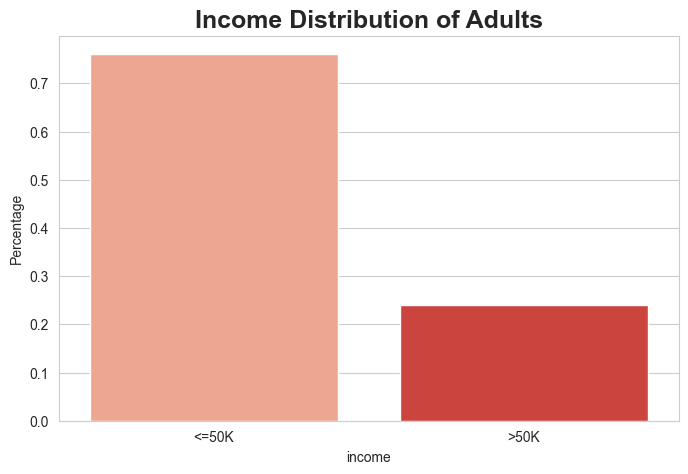

In [23]:
plt.figure(figsize = (8,5))
plt.title('Income Distribution of Adults', fontsize=18, fontweight='bold')
eda_percentage = dt['income'].value_counts(normalize = True).rename_axis('income').reset_index(name = 'Percentage')
sns.barplot(x = 'income', y = 'Percentage', data = eda_percentage.head(10), palette='Reds')

     

**Here, we can see that number of people earning more than 50K dollars an year is one third of the people earning less than it.**

C:\Users\Mitrahang\AppData\Local\Temp\ipykernel_21332\2039541196.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


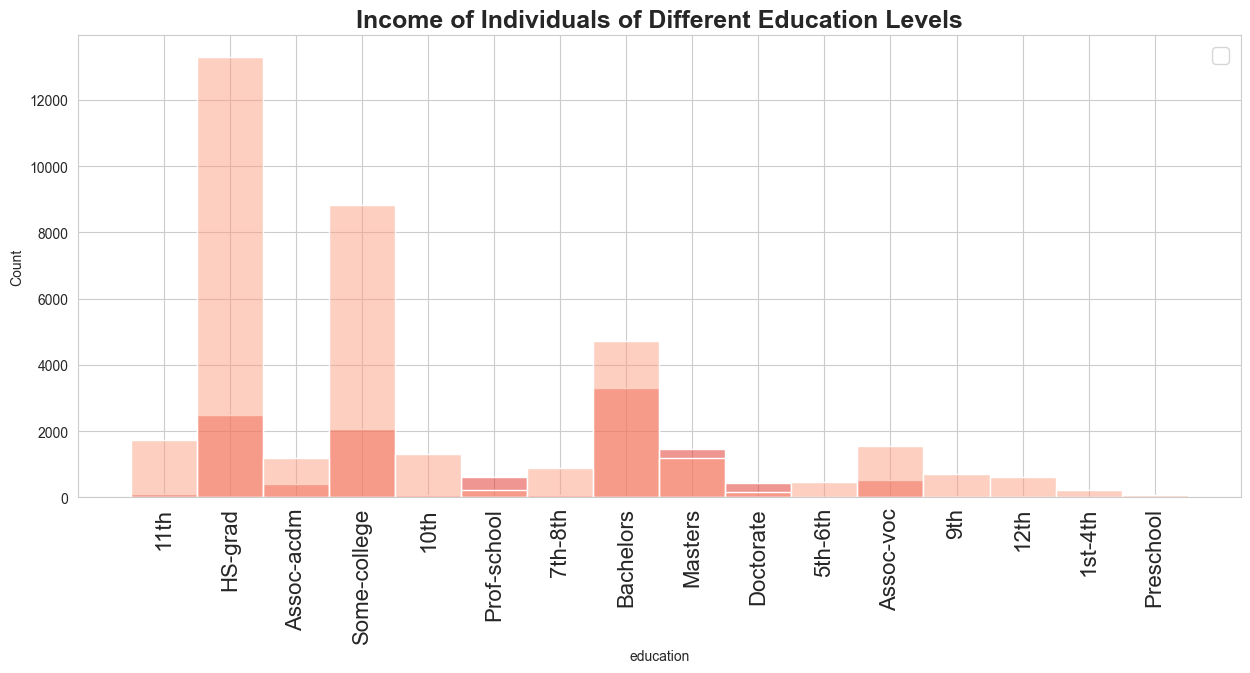

In [26]:
plt.figure(figsize=(15,6))
sns.histplot(x = dt['education'], hue = dt['income'], palette='Reds')
plt.title('Income of Individuals of Different Education Levels', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16,rotation = 90)
plt.legend(fontsize=16)

**This shows that most people with education up to 12th grade earn below 50K. In contrast, people with Bachelor’s, Master’s, Doctorate, or Professional degrees are more likely to earn above 50K. Associate degree holders have relatively few people earning over $50K.**

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000'),
  Text(0, 12000.0, '12000')])

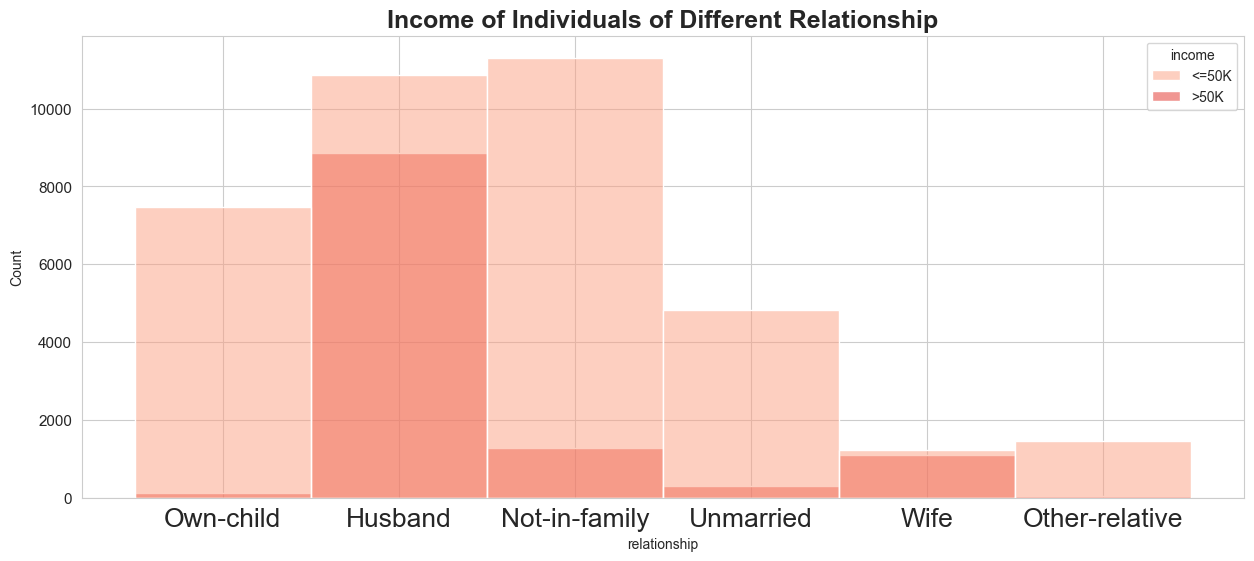

In [27]:

plt.figure(figsize=(15,6))
sns.histplot(x = dt['relationship'], hue = dt['income'], palette = 'Reds')
plt.title('Income of Individuals of Different Relationship', fontsize=18, fontweight='bold')
plt.xticks(fontsize = 19)
plt.yticks(fontsize = 11)

**This shows that husbands have the highest number of people earning above 50K. Wives also have a significant number of people earning above 50K, while only a few unmarried and other relationship groups earn more than 50K.**

C:\Users\Mitrahang\AppData\Local\Temp\ipykernel_21332\2208694135.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


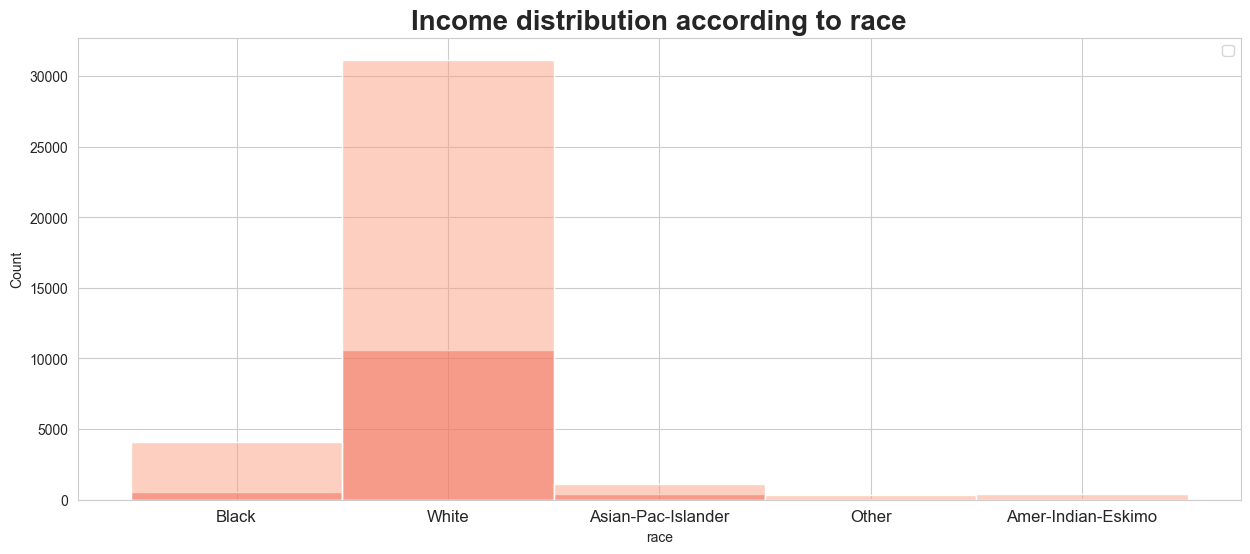

In [28]:
plt.figure(figsize=(15,6))
sns.histplot(x = dt['race'], hue =dt['income'], palette = 'Reds')
plt.title('Income distribution according to race', fontsize = 20, fontweight ='bold')
plt.xticks(fontsize = 12)
plt.legend()

**This shows that the White group has the highest number of people earning above 50K. The Black group also has some people earning above 50K, while the other groups have relatively fewer people earning above 50K.**

(array([    0.,  5000., 10000., 15000., 20000., 25000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000')])

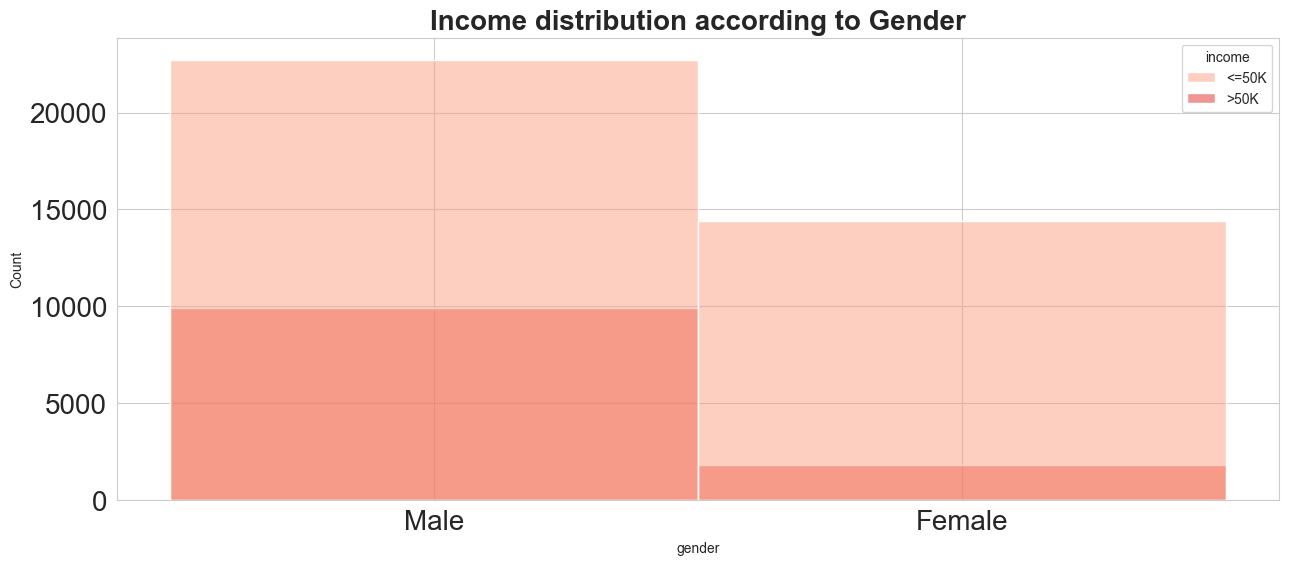

In [29]:
plt.figure(figsize=(15,6))
sns.histplot(data =dt, x = dt['gender'], hue = dt['income'], palette='Reds')
plt.title('Income distribution according to Gender', fontsize = 20, fontweight ='bold')
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)


**This shows that males have a higher number of people earning above 50K than females. However, most females earn 50K or less, while males have a more balanced distribution between the two income groups.**

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'age'),
  Text(0, 1.5, 'fnlwgt'),
  Text(0, 2.5, 'educational_num'),
  Text(0, 3.5, 'capital_gain'),
  Text(0, 4.5, 'capital-loss'),
  Text(0, 5.5, 'hours_per_week')])

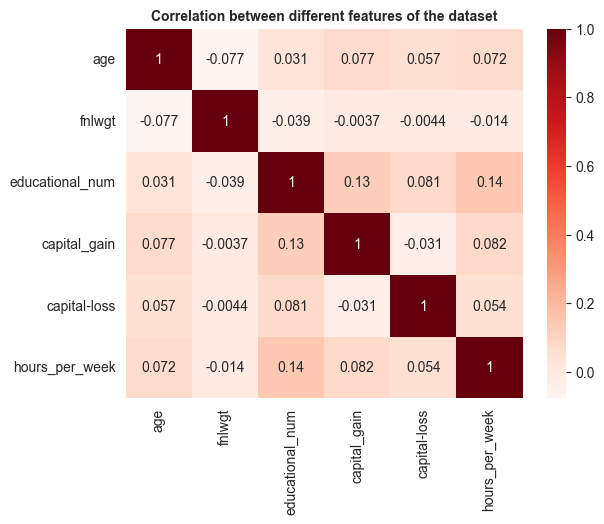

In [30]:
numeric_data = dt.select_dtypes(include='number')
plt.title("Correlation between different features of the dataset", fontsize=10, fontweight='bold')
sns.heatmap(numeric_data.corr(), cmap='Reds', annot=True)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)

**The correlation heatmap shows that most features have very weak correlations with each other. The strongest relationship is between educational_num and hours_per_week, while fnlwgt has almost no correlation with the other features. Overall, there is no strong correlation between the numerical features.**